This notebook compiles the results of the chosen ALIF parameters:

    - plots example encoded spikes
    - plots comparison to MU decoders
    - plots the range of EMG amplitudes
    - plot example prediction from the encoding pipeline

In [1]:
import os
import sys
notebook_dir = os.getcwd()
project_dir = os.path.dirname(os.path.dirname(notebook_dir))

if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

import logging
import json
import re
import torch
from matplotlib import gridspec
from typing import List,Dict
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle as pkl
import dataframe_image as dfi
import matplotlib.patches as mpatches
import matplotlib as mpl

from hydra import initialize_config_dir, compose
import force_regression.utils.configuration as lrc
import force_regression.utils.io as io
import force_regression.training.snn_pipeline as snn_prep
from force_regression.config.dataconfig import DataConfig
import force_regression.utils.functions as fn
import force_regression.evaluation.compile_results as cr
from force_regression.models.snn import *
from configs.constants import *

print(f'Notebook dir: {notebook_dir}\nProject dir: {project_dir}.')

logging.getLogger().setLevel(logging.INFO)
%load_ext autoreload
%autoreload 2

Notebook dir: /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/notebooks/analysis
Project dir: /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding.


In [2]:
config_path = os.path.join(project_dir, 'configs/config.json')

try:
    with open(config_path, 'r') as config_file:
        config = json.load(config_file)
        root_dir = os.path.join(project_dir, config['root_dir'])
        root_results_dir = os.path.join(project_dir, config['root_results_dir'])
        config['root_dir'] = root_dir
        config['root_results_dir'] = root_results_dir

        subject_mappings = config['subject_mappings']
        print(f'Root directory from config: {root_dir}')
except FileNotFoundError:
    print(f"Error: 'config.json' not found in {config_path}")
except json.JSONDecodeError:
    print("Error: 'config.json' is not a valid JSON file.")
except KeyError:
    print("Error: 'root_dir' not found in 'config.json'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Root directory from config: /Volumes/big usb drive/HDiEMG_mu_decomposition


# Load data configuration

In [13]:
data_config = DataConfig(root_dir=root_dir,
                    root_results_dir = root_results_dir,
                    subject=fn.reverse_remap('S1', subject_mappings),
                    task_type="Trap", 
                    finger_type="Individual",
                    day="Day 1", mvc=15,
                    emg_type="intra",
                    subj_map=subject_mappings,
                    segment_hold=False,
                    verbose=False,
                    common_only=True,
                    images=True,
                    time_to_cut=1,
                    convreg_temp_data_dir='regression_data',
                    figs_dir = 'figures')
results_path = os.path.join(data_config.results_path, f'SNN/{ENC_SHALLOW_LEAKY}')
output_figures_dir = os.path.join(data_config.root_results_dir, data_config.figs_dir)
results_dir = 'output_files'

source_data_main_file = 'SourceDataMain_2.xlsx'
source_data_supp_file ='SourceDataSupplementary.xlsx'



# Load SNN configuration

In [14]:
# load SNN configuratio using hydra
abs_config_dir=os.path.abspath("../../configs/hydra")
with initialize_config_dir(version_base=None, config_dir=abs_config_dir):
    cfg = compose(config_name="snn",
                overrides=["decoder_type=encoding",
                            "logging.wandb.use_wandb=False",
                            ])
    cfg_leaky = compose(config_name="snn",
                  overrides=["decoder_type=leaky",
                            "logging.wandb.use_wandb=False",
                             ])
    cfg_spiking = compose(config_name="snn",
                  overrides=["decoder_type=spiking",
                            "logging.wandb.use_wandb=False",
                             ])
flat_config = lrc.flatten_hydra_config(cfg)
flat_leaky_config = lrc.flatten_hydra_config(cfg_leaky)
flat_spiking_config = lrc.flatten_hydra_config(cfg_spiking)



# Utility functions

In [15]:
# Load all rec_rep_ + parse parameters from the filename
def parse_parameters_from_filename(filename: str, sub: str) -> Dict[str, any]:
    """
    Parse parameters from the filename and return them as a dictionary.
    """
    params = {}
    params[REP_ID] = int(re.search(r'rec_rep_(\d+)', filename).group(1))
    params[MVC_COL] = int(re.search(r'mvc_(\d+)', filename).group(1))
    params[SUBJECT_COL] = sub
    params[EMG_COL] = 'intra'
    params[INPUT_TYPE_COL] = INPUT_TYPE_SP_TIMES
    params[SIGN_MVC_COL] = int(re.search(r'sign_([+-]?\d+)', filename).group(1))
    params[EPOCHS_COL] = int(re.search(r'cv_snn_ep_(\d+)', filename).group(1))
    
    tau_syn_match = re.search(r'tausyn_([+-]?([0-9]*[.])?[0-9]+)', filename)
    params[TAU_SYN_COL] = float(tau_syn_match.group(1)) if tau_syn_match is not None else 0
    
    tau_mem_match = re.search(r'taumem_([+-]?([0-9]*[.])?[0-9]+)', filename)
    params[TAU_MEM_COL] = float(tau_mem_match.group(1)) if tau_mem_match is not None else 0

    tau1_mem_filt_match = re.search(r'taufilt1_([+-]?([0-9]*[.])?[0-9]+)', filename)
    tau2_mem_filt_match = re.search(r'taufilt2_([+-]?([0-9]*[.])?[0-9]+)', filename)
    params[TAU1_MEM_FILT_COL] = float(tau1_mem_filt_match.group(1)) if tau1_mem_filt_match is not None else 0
    params[TAU2_MEM_FILT_COL] = float(tau2_mem_filt_match.group(1)) if tau2_mem_filt_match is not None else 0
    
    params[REG_FING_COL] = np.arange(1, 6, 1) if params[MVC_COL] < 20 else np.arange(1, 4, 1)

    torch_seed_match = re.search(r'seed_(\d+)', filename)
    params[TORCH_SEED_COL] = int(torch_seed_match.group(1)) if torch_seed_match is not None else None

    noise_seed_match = re.search(r'ns_(\d+)', filename)
    noise_level_match = re.search(r'noise_(\d+)', filename)
    if noise_level_match is not None:
        params[NOISE_SEED_COL] = int(noise_seed_match.group(1))
        params[OMISSION_LEVEL_COL] = int(noise_level_match.group(1))

    hold_flag = cr.search_for_pattern_in_filename(filename, r'hold_(True|False)')
    params[SEGMENT_HOLD_COL] = hold_flag == 'True' if hold_flag is not None else None

    learn_tausyn_match = cr.search_for_pattern_in_filename(filename, r'sinit_([+-]?([0-9]*[.])?[0-9]+)')
    params[TAU_SYN_INIT_COL] = float(learn_tausyn_match) if learn_tausyn_match is not None else 0

    learn_taumem_match = cr.search_for_pattern_in_filename(filename, r'minit_([+-]?([0-9]*[.])?[0-9]+)')
    params[TAU_MEM_INIT_COL] = float(learn_taumem_match) if learn_taumem_match is not None else 0


    enctau1 = re.search(r'enctau1_([+-]?([0-9]*[.])?[0-9]+)', filename)
    is_aleaky = re.search(r'aleaky_', filename)
    if enctau1 is not None:
        enctau1 = float(enctau1.group(1))
        enctau2 = float(re.search(r'enctau2_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        enctau3 = float(re.search(r'enctau3_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        params[ENC_TAU_MEM1_COL] = enctau1
        params[ENC_TAU_MEM2_COL] = enctau2
        params[ENC_TAU_MEM3_COL] = enctau3
    else:
        enctau1 = float(re.search(r'enctau_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        params[ENC_TAU_MEM1_COL] = enctau1

    encthr1 = re.search(r'encthresh1_([+-]?([0-9]*[.])?[0-9]+)', filename)
    if encthr1 is not None:
        encthr1 = float(encthr1.group(1))
        encthr2 = float(re.search(r'encthresh2_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        encthr3 = float(re.search(r'encthresh3_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        params[ENC_SPK_THRESH1_COL] = encthr1
        params[ENC_SPK_THRESH2_COL] = encthr2
        params[ENC_SPK_THRESH3_COL] = encthr3
    else:
        encthr1 = float(re.search(r'encthresh_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        params[ENC_SPK_THRESH1_COL] = encthr1

    if is_aleaky:
        params[USE_ALIF_COL] = True
        threshold_tau_adapt = float(re.search(r'tauadapt_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        threshold_scale_adapt = float(re.search(r'scaleadapt_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        params[ENC_THRESHOLD_TAU_COL] = threshold_tau_adapt
        params[ENC_ALIF_SCALE_COL] = threshold_scale_adapt
    else:
        params[USE_ALIF_COL] = False
        params[ENC_THRESHOLD_TAU_COL] = None
        params[ENC_ALIF_SCALE_COL] = None
    return params

In [16]:
def stitch_tensor(unfolded_var_tensor, dataset, mvc, bin_size, rep_one_indexed, overlap_ratio=0.5):
        """
        Stitches the output spikes into a single tensor for plotting
        """
        stitched_per_finger = {}
        n_fingers= unfolded_var_tensor.size(-1)
        segments_start_times = dataset.segments_start[mvc] 
        segment_n_steps = int(bin_size/dataset.dt)
        stride_in_steps = int(bin_size* (1 - overlap_ratio)/dataset.dt)

        tensor_size = int(dataset.segments_start[mvc][-1]/dataset.dt + segment_n_steps)
        print(f"Tensor size:{tensor_size}")
        arr_pointer = 0
        active_fingers_order = dataset.active_fingers_order[rep_one_indexed]
        for target_finger in active_fingers_order:
            stitched_spikes = np.zeros((tensor_size, n_fingers))
            for slice_i, _ in enumerate(segments_start_times):
                slice_start_loc = slice_i * stride_in_steps
                slice_end_loc = slice_start_loc + segment_n_steps
                stitched_spikes[slice_start_loc: slice_end_loc] = unfolded_var_tensor[0, arr_pointer : arr_pointer+ segment_n_steps, :]
                arr_pointer += segment_n_steps
            stitched_per_finger[target_finger] = stitched_spikes
        return stitched_per_finger

In [17]:
def get_encoded_spikes_emg_and_force(subject:str,
                                    rep_id_one_indexed:int,
                                    sign_mvc:int,
                                    use_alif:bool,
                                    threshold_tau_adapt:float,
                                    threshold_scale_adapt:float,
                                    baseline_threshold:float,
                                    flat_config,
                                    select_torch_seed:int,
                                    dataset):
    
    data_config = DataConfig(root_dir=root_dir,
                    root_results_dir = root_results_dir,
                    subject=fn.reverse_remap(subject, subject_mappings),
                    task_type="Trap", 
                    finger_type="Individual",
                    day="Day 1", mvc=15,
                    emg_type="intra",
                    subj_map=subject_mappings,
                    segment_hold=False,
                    verbose=False,
                    common_only=True,
                    images=True,
                    time_to_cut=1,
                    convreg_temp_data_dir='regression_data',
                    results_dir = 'output_files',
                    figs_dir = 'figures')
    data_config.sign_mvc = sign_mvc
    mvc = data_config.mvc
    # Load EMG and force data
    emg_force_df = snn_prep.load_emg_data_for_snn(data_config, load_from_file=True)

    # Load recoded SNN variables
    results_path = os.path.join(data_config.results_path, f'SNN/{ENC_SHALLOW_LEAKY}')
    print(f"Looking for recorded SNN variables in: {results_path}")
    rec_ts = None
    for filename in os.listdir(results_path):
        if not filename.startswith('rec_rep_') or not filename.endswith('.pkl'):
            continue
        
        # parse parameters from the filename
        params = parse_parameters_from_filename(filename, subject)

        # check if the parameters match
        if (params[REP_ID] == rep_id_one_indexed and
            params[SIGN_MVC_COL] == sign_mvc and
            params[MVC_COL] == mvc and
            params[ENC_SPK_THRESH1_COL] == baseline_threshold and
            params[USE_ALIF_COL] == use_alif and
            params[ENC_THRESHOLD_TAU_COL] == threshold_tau_adapt and
            params[ENC_ALIF_SCALE_COL] == threshold_scale_adapt and
            params[TORCH_SEED_COL] == select_torch_seed and 
           params[EPOCHS_COL] == 100):

            print(f"Matching file found!")
            
            filepath = os.path.join(results_path,filename)
            print(f"Loading recorded SNN variables from: {filename}\n path:{results_path}\n")

            with open(filepath, 'rb') as handle:
                rec_ts = pkl.load(handle)
                break
            
    if rec_ts is None:
        print(f"No matching file found for rep {rep_id_one_indexed}, sign_mvc {sign_mvc}, thresholds {baseline_threshold}, tau_adapt {threshold_tau_adapt}, scale_adapt {threshold_scale_adapt}.")

    if rec_ts is None:
        print(f"No recorded data found for rep {rep_id_one_indexed}, sign_mvc {sign_mvc}, thresholds {baseline_threshold}, tau_adapt {threshold_tau_adapt}, scale_adapt {threshold_scale_adapt}. Skipping.")
    else:
        print(f"rec_ts keys: {rec_ts.keys()}")

    bin_size = flat_config.inf_rep_binwidth
    overlap_ratio = flat_config.overlap_perc
    emg_encoded = rec_ts[ENC_SPK_OUT]
    stitched_emg_encoded_per_finger = stitch_tensor(emg_encoded,
                                                   dataset, mvc,
                                                   bin_size,
                                                   rep_id_one_indexed, overlap_ratio)
 
    return stitched_emg_encoded_per_finger, emg_force_df

# Plot encoded spikes and overlayed force

In [18]:
def raster_plot_encoded_and_force(data_config:DataConfig, sim_dt:float,
                                  stitched_emgenc_per_finger:Dict[int, np.ndarray],
                                  emg_force_df:pd.DataFrame,
                                  mvc:int, sign_mvc:int, rep:int, subject:str,
                                  scale_adapt:float,
                                  n_fingers:int=5, n_electrodes:int=3,
                                  n_channels_per_electrode:int=40,
                                  save_fig=False, output_figures_dir:str=None,
                                  source_data_path:str=None,
                                  sheet_name:str='alif_encoded_raster'):
    
    n_channels = n_channels_per_electrode * n_electrodes
    channel_start_per_electrode = np.arange(0, n_channels_per_electrode*n_electrodes, n_channels_per_electrode)

    fig = plt.figure(figsize=(7, 2.5))
    gs = gridspec.GridSpec(nrows=1, ncols=n_fingers)

    force_color = COLORS['midnight_blue']
    enc_alpha = [0.06, 0.06, 0.06]
    force_alpha = 0.8
    force_yticks_step = 5
    time_xticks_step = 10
    yaxes_buffer = 2
    for finger in range(n_fingers):
        finger_name = list(data_config.get_fingers().keys())[finger].lower()

        spike_times = np.where(stitched_emgenc_per_finger[finger+1] > 0)[0] * sim_dt
        spike_ids = np.where(stitched_emgenc_per_finger[finger+1] > 0)[1]
        duration = len(stitched_emgenc_per_finger[finger+1]) * sim_dt
        
        ax = fig.add_subplot(gs[finger])
        for e in range(n_electrodes):
            ch_start = channel_start_per_electrode[e]
            ch_end = ch_start + n_channels_per_electrode
            spike_times_electrode = spike_times[(spike_ids >= ch_start) & (spike_ids < ch_end)]
            spike_ids_electrode = spike_ids[(spike_ids >= ch_start) & (spike_ids < ch_end)]
            ax.plot(spike_times_electrode, spike_ids_electrode, "|", ms=2,
                    color=COLORS['burgundy'], alpha=enc_alpha[e])

        ax2 = ax.twinx()
        force_df = emg_force_df[emg_force_df['finger_id']==finger+1][f'force_rep{rep}'].values[0]
        ax2.plot(force_df['time'], force_df[f'force_{finger_name}'], color=force_color, alpha=force_alpha)

        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.spines['bottom'].set_visible(False)
        ax2.spines['left'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)

        if finger == n_fingers-1:
            ax2.set_ylabel(FORCE_MVC_LABEL, fontsize=LABEL_FONTSIZE, color=force_color)
            ax2.set_yticks(np.arange(0, mvc + force_yticks_step, force_yticks_step))
        else:
            ax2.set_yticks([])
        ax2.set_ylim([0, mvc + yaxes_buffer])
        ax.set_title(f"{finger_name}", fontsize=TITLE_FONTSIZE)
        if finger == 0:
            ax.set_ylabel('Neuron ID', fontsize=LABEL_FONTSIZE, labelpad=YLAB_PAD)
        ax.set_xlabel(TIME_LABEL, fontsize=LABEL_FONTSIZE)
        ax.set_yticks(np.arange(0, n_channels + force_yticks_step, n_channels_per_electrode))
        ax.set_ylim([0, n_channels + n_channels_per_electrode + yaxes_buffer])
        ax.set_xticks(np.arange(0, duration, time_xticks_step))
        if finger > 0:
            ax.set_yticks([])
        sns.despine(ax=ax, trim=False, left=True, top=True, right=True, bottom=True)
    fig.tight_layout()

    if source_data_path is not None:
        _sheet = sheet_name if sheet_name else f"{subject}_alif_raster_rep{rep}"
        rows = []
        for finger in range(n_fingers):
            finger_name = list(data_config.get_fingers().keys())[finger].lower()
            spike_times = np.where(stitched_emgenc_per_finger[finger+1] > 0)[0] * sim_dt
            spike_ids = np.where(stitched_emgenc_per_finger[finger+1] > 0)[1]
            for t, mu in zip(spike_times.tolist(), spike_ids.tolist()):
                rows.append({'finger': finger_name, 'spike_time_s': round(t, 6), 'channel_id': int(mu)})
        io.save_to_source_data(source_data_path, pd.DataFrame(rows), sheet_name=_sheet)
        force_df_all = emg_force_df.iloc[0][f'force_rep{rep}'].copy()
        force_cols = [c for c in force_df_all.columns if 'force' in c]
        force_df_all = force_df_all[['time'] + force_cols].rename(columns={'time': 'time_s'})
        print(force_df_all.shape)

        print(force_df_all.columns)
        io.save_to_source_data(source_data_path, force_df_all, sheet_name=f"{_sheet}_force")


    if save_fig:
        fig_name = f"{subject}_raster_plot_alif_encoded_and_force_mvc_{mvc}_sign_{sign_mvc}_rep_{rep}_scale_adapt_{scale_adapt}.pdf"
        fig_path = os.path.join(output_figures_dir, fig_name)
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved at {fig_path}")

In [19]:
# load EMG dataset
dataset_filename = 'emgdataset_encoding_offline.pkl'
dataset_filepath = os.path.join(data_config.snn_temp_data_path, dataset_filename)
print(f"Dataset filepath:{dataset_filepath}")
#read the dataset
with open(dataset_filepath, 'rb') as handle:
    dataset = pkl.load(handle)

Dataset filepath:/Volumes/big usb drive/snn-fingerforce-decoding-results/results/snn_data/S1/emgdataset_encoding_offline.pkl


In [20]:
subject = 'S1'

rep_id_one_indexed = 2
sign_mvc = 1
use_alif = True

threshold_tau_adapt = 0.1
threshold_scale_adapt = 0.5
baseline_threshold = 0.1
select_torch_seed = 90
mvc = flat_config.mvc[0]

stitched_emgenc_per_finger, emg_force_df = get_encoded_spikes_emg_and_force(subject,
                                                                        rep_id_one_indexed,
                                                                        sign_mvc,
                                                                        use_alif,
                                                                        threshold_tau_adapt,
                                                                        threshold_scale_adapt,
                                                                        baseline_threshold,
                                                                        flat_config,
                                                                        select_torch_seed,
                                                                        dataset,
                                                                        
                                                                        )

INFO:root:Loaded regression data for finger 1
INFO:root:Loaded regression data for finger 2
INFO:root:Loaded regression data for finger 3
INFO:root:Loaded regression data for finger 4
INFO:root:Loaded regression data for finger 5


Looking for recorded SNN variables in: /Volumes/big usb drive/snn-fingerforce-decoding-results/results/output_files/S1/SNN/encoding_shallow_leaky
Matching file found!
Loading recorded SNN variables from: rec_rep_2_cv_snn_ep_100_seed_90_noise_None_ns_100_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.1_encthresh2_0.1_encthresh3_0.1_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.5_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
 path:/Volumes/big usb drive/snn-fingerforce-decoding-results/results/output_files/S1/SNN/encoding_shallow_leaky

rec_ts keys: dict_keys(['emg_in', 'enc_neu_cur', 'enc_neu_mem', 'enc_out', 'leak_syn_cur', 'leak_neu_cur', 'spk_out', 'leak_neu_mem', 'filt_neu_mem', 'filt_spk_out', 'enc_threshold_adapt', 'enc_alif_threshold'])
Tensor size:3000


Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataMain_2.xlsx in sheet 'Fig8b_alif'.
(286081, 6)
Index(['time_s', 'force_thumb', 'force_index', 'force_middle', 'force_ring',
       'force_little'],
      dtype='object')
Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataMain_2.xlsx in sheet 'Fig8b_alif_force'.


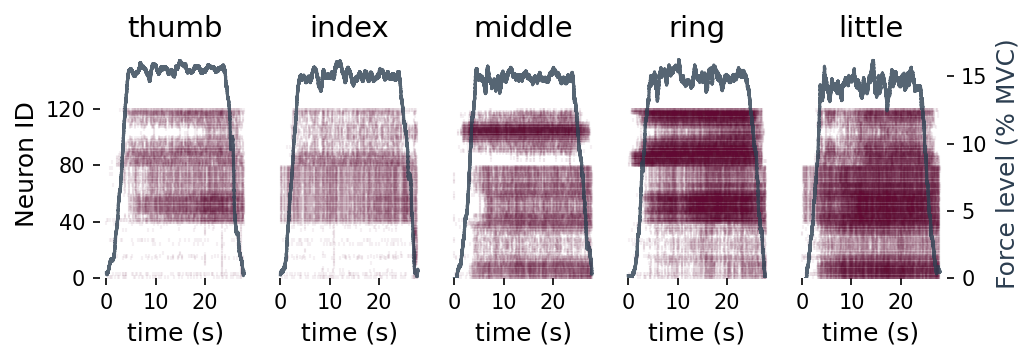

In [22]:
raster_plot_encoded_and_force(data_config,
                              flat_config.dt,
                              stitched_emgenc_per_finger,
                              emg_force_df,
                              mvc, sign_mvc,
                              rep_id_one_indexed,
                              subject,
                              scale_adapt=threshold_scale_adapt,
                              save_fig=False,
                              output_figures_dir=output_figures_dir,
                              source_data_path=os.path.join(project_dir, source_data_main_file),
                              sheet_name = "Fig8b_alif")

# Plot range of EMG amplitudes

In [52]:
def plot_emg_amplitude_boxplots(emg_force_df: pd.DataFrame,
                                 data_config,
                                 subject,
                                 sign_mvc:int,
                                 n_reps: int = 2,
                                 per_channel: bool = False,
                                 save_fig: bool = False,
                                 output_figures_dir: str = None,
                                 fig_name: str = None,
                                 source_data_path=None,
                                 sheet_name=f'Fig_amplitude_boxplot'):
    """
    Plot EMG amplitude ranges across tasks (fingers) as boxplots.
    
    Parameters:
    -----------
    emg_force_df : pd.DataFrame
        DataFrame with columns: finger_id, emg_filt_rep1, emg_filt_rep2, etc.
        Each emg_filt_rep cell contains array of shape (n_channels, time) = (120, 286081)
    data_config : object
        Data configuration object with finger mappings
    n_reps : int
        Number of repetitions (default 2)
    per_channel : bool
        If True, show amplitude range per channel. If False, show overall amplitude distribution.
    save_fig : bool
        Whether to save the figure
    output_figures_dir : str
        Directory to save the figure
    fig_name : str
        Name of the output figure file
    """
    finger_names = list(data_config.get_fingers().keys())
    n_fingers = len(finger_names)
    
    # Collect amplitude ranges per finger
    boxplot_data = []
    finger_labels = []
    
    for finger_id in range(1, n_fingers + 1):
        finger_name = finger_names[finger_id - 1].lower()
        finger_row = emg_force_df[emg_force_df['finger_id'] == finger_id]
        
        if finger_row.empty:
            continue
        
        all_ranges = []
        for rep in range(1, n_reps + 1):
            emg_col = f'emg_filt_rep{rep}'
            if emg_col in finger_row.columns:
                emg_array = finger_row[emg_col].values[0]  # Shape: (120, time)
                
                if per_channel:
                    # Get amplitude range (max - min) per channel
                    channel_ranges = np.ptp(emg_array, axis=1)  # peak-to-peak per channel
                    all_ranges.extend(channel_ranges)
                else:
                    # Get max absolute amplitude per channel
                    channel_max = np.max(np.abs(emg_array), axis=1)
                    all_ranges.extend(channel_max)
        
        if all_ranges:
            boxplot_data.append(all_ranges)
            finger_labels.append(finger_name)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(4, 2.5))
    
    # Prepare data for seaborn
    plot_df = pd.DataFrame({
        'Finger': np.repeat(finger_labels, [len(d) for d in boxplot_data]),
        'Amplitude': np.concatenate(boxplot_data)
    })
    
    sns.violinplot(data=plot_df, x='Finger', y='Amplitude', ax=ax,
                   color=COLORS["burgundy"], alpha=0.6, 
                   inner='box',  # shows mini boxplot inside
                   linewidth=1.2)
    
    # Add scatter points next to violins
    sns.stripplot(data=plot_df, x='Finger', y='Amplitude', ax=ax,
                  color=COLORS["midnight_blue"], alpha=0.4, size=3, jitter=0.05)
    
    ylabel = "Amplitude Range (mV)" if per_channel else "EMG Max Amplitude (mV)"
    ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE )
    ax.set_xlabel("", fontsize=LABEL_FONTSIZE + 2)
    ax.set_ylim([-1.5,8])
    # ax.set_title("EMG Amplitude Distribution Across Channels", fontsize=TITLE_FONTSIZE)
    ax.tick_params(axis='both', labelsize=LABEL_FONTSIZE)
    
    sns.despine(ax=ax)
    fig.tight_layout()

    
    if save_fig and output_figures_dir:
        # io.save_to_source_data(source_data_path, plot_df, sheet_name=sheet_name)
        save_df = pd.DataFrame({
        finger: pd.Series(amplitudes)
        for finger, amplitudes in zip(finger_labels, boxplot_data) })
        io.save_to_source_data(source_data_path, save_df, sheet_name=sheet_name)

        if fig_name is None:
            fig_name = f"{subject}_emg_amplitude_boxplot_mvc_{mvc}_sign_{sign_mvc}_acrossreps.pdf"
        fig_path = os.path.join(output_figures_dir, fig_name)
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved at {fig_path}")


    
    return fig, ax


In [53]:
subject, sign_mvc

('S2', -1)

Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataSupplementary.xlsx in sheet 'SFig10d_emgamplitude'.
Figure saved at /Volumes/big usb drive/snn-fingerforce-decoding-results/results/figures/S2_emg_amplitude_boxplot_mvc_15_sign_-1_acrossreps.pdf


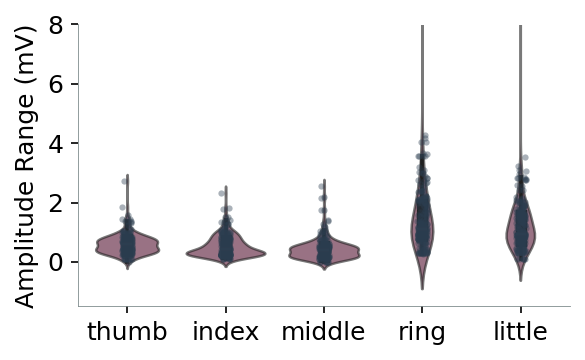

In [55]:
# Show amplitude range (max - min) per channel
fig, ax = plot_emg_amplitude_boxplots(
    emg_force_df,
    data_config=data_config,
    subject=subject,
    sign_mvc=sign_mvc,
    n_reps=2,
    per_channel=True,  # True for peak-to-peak range, False for max absolute amplitude
    save_fig=True,
    output_figures_dir=output_figures_dir,
    source_data_path=os.path.join(project_dir, source_data_supp_file),
    sheet_name=f'SFig10d_emgamplitude'
)

# Comparison to MU-decoders per direction

In [23]:
def combine_metrics_df_for_topology(subjects:List[str],
                                    topologies:List[str],
                                    metrics_list:List[str],
                                    config:DataConfig,
                                    save_dfs:bool=False):
    """
    Combine the metrics dataframes for each topology and compute the mean and std for each metric 
    during inference
    """
    metrics_list_with_mean_std = [f"{metric}_mean" for metric in metrics_list] + [f"{metric}_std" for metric in metrics_list]
    snn_topologies_df = pd.DataFrame()
    all_samples_df = pd.DataFrame()

    selected_scale = 0.1
    selected_tau = 0.1
    selected_thr = 0.1
    for topology in topologies:
        topology_df = cr.load_and_parse_snn_data_to_df(dt=0.01, subject_list=subjects,
                                                       data_type='metrics_df_cv_snn',
                                                       network_topology=f'{topology}',
                                                       results_dir=results_dir,
                                                       config=config)
        if topology == ENC_SHALLOW_LEAKY:
            topology_df = topology_df[(topology_df[ENC_ALIF_SCALE_COL] == selected_scale) & 
                                    (topology_df[ENC_THRESHOLD_TAU_COL] == selected_tau) & 
                                    (topology_df[ENC_SPK_THRESH1_COL]==selected_thr)&
                                    (topology_df[EPOCHS_COL] == 100)]

        topology_df_inf = topology_df[topology_df[MODE_COL] == 'inference']

        mean_metrics = topology_df_inf.groupby([SUBJECT_COL, SIGN_MVC_COL])[metrics_list].mean().reset_index()
        print(f"Topology={topology}\nComputing mean across n={ topology_df_inf.groupby([SUBJECT_COL, SIGN_MVC_COL])[metrics_list].count()}\n\n")
        std_metrics = topology_df_inf.groupby([SUBJECT_COL, SIGN_MVC_COL])[metrics_list].std().reset_index()
        mean_std_metrics_df_per_direction = pd.merge(mean_metrics, std_metrics, on=[SUBJECT_COL, SIGN_MVC_COL], suffixes=('_mean', '_std'))
        
        # Get the mean and std across directions
        df_across_directions = mean_std_metrics_df_per_direction.groupby([SUBJECT_COL], as_index=False)[metrics_list_with_mean_std].mean()
        mean_std_metrics_df_per_direction[TOPOLOGY_COL] = topology
        snn_topologies_df = pd.concat([snn_topologies_df, mean_std_metrics_df_per_direction], ignore_index=True)
        topology_df_inf[TOPOLOGY_COL] = topology
        all_samples_df = pd.concat([all_samples_df, topology_df_inf], ignore_index=True)


        if save_dfs:
            file_prefix = f'{topology}_average_metrics_table_mvc_15'
            df_across_directions.to_csv(os.path.join(output_figures_dir,f"{file_prefix}.csv"), index=False)
            mean_std_metrics_df_per_direction.to_csv(os.path.join(output_figures_dir,f"{file_prefix}_per_direction.csv"), index=False)

    return snn_topologies_df, all_samples_df

In [24]:
subjects = ["S1","S2"]
metrics_list = [RMSE_TEST, R2_TEST, MAE_TEST]
topologies =[ENC_SHALLOW_LEAKY, SHALLOW_LEAKY, SHALLOW_SPIKING_DOUBLE_FILTER]

snn_topologies_df, samples_df= combine_metrics_df_for_topology(subjects,
                                                                 topologies,
                                                                 metrics_list,
                                                                 config,
                                                                 save_dfs=False)

Loading data for subject S1 from /Volumes/big usb drive/snn-fingerforce-decoding-results/results/output_files/S1/SNN/encoding_shallow_leaky
Loading file: metrics_df_cv_snn_ep_100_seed_8_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.1_encthresh2_0.1_encthresh3_0.1_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.1_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_None_ns_100_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.01_encthresh2_0.01_encthresh3_0.01_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.1_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_None_ns_100_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.4_encthresh2_0.4_encthresh3_0.4_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_1_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_None_ns_100_taufilt1_0.2_

Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_None_ns_100_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.2_encthresh2_0.2_encthresh3_0.2_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_1_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_None_ns_100_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.04_encthresh2_0.04_encthresh3_0.04_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_1_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_None_ns_100_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.01_encthresh2_0.01_encthresh3_0.01_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.5_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_15_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.1_encthresh2_0.1_encthresh3_0.1_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0

Loading file: metrics_df_cv_snn_ep_100_seed_90_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.1_encthresh2_0.1_encthresh3_0.1_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.1_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.08_encthresh2_0.08_encthresh3_0.08_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.1_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.1_encthresh2_0.1_encthresh3_0.1_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.1_encthresh2_0.1_encthresh3_0.1_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.1_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loadi

Loading file: metrics_df_cv_snn_ep_100_seed_9_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_28_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_28_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_64_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_15_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_0_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_64_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_

Loading file: metrics_df_cv_snn_ep_100_seed_73_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_89_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Topology=shallow_leaky
Computing mean across n=                  RMSE_test  R2_test  MAE_test
subject sign_mvc                              
S1      -1              100      100       100
         1              100      100       100
S2      -1              100      100       100
         1              100      100       100


Loading data for subject S1 from /Volumes/big usb drive/snn-fingerforce-decoding-results/results/output_files/S1/SNN/shallow_spiking_double_filter
Loading file: metrics_df_cv_snn_ep_100_seed_8_noise_None_ns_100_taufilt1_0.05_taufilt2_0.08_ta

In [25]:
snn_topologies_df

,subject,sign_mvc,RMSE_test_mean,R2_test_mean,MAE_test_mean,RMSE_test_std,R2_test_std,MAE_test_std,topology
0,S1,-1,2.660534,0.711524,1.858926,1.297155,0.289525,0.890991,encoding_shallow_leaky
1,S1,1,2.871439,0.618362,1.860175,1.809450,0.393458,1.195541,encoding_shallow_leaky
2,S2,-1,2.481361,0.785981,1.892088,1.037882,0.159093,0.904348,encoding_shallow_leaky
3,S2,1,3.338534,0.607822,2.369989,1.105862,0.216558,0.750772,encoding_shallow_leaky
4,S1,-1,1.95791,0.870352,1.224726,0.382910,0.050517,0.344841,shallow_leaky
5,S1,1,1.498565,0.919254,0.962427,0.382516,0.037286,0.231677,shallow_leaky
6,S2,-1,2.157862,0.856126,1.569748,0.358911,0.038290,0.387426,shallow_leaky
7,S2,1,2.465921,0.791434,1.708747,0.729109,0.106439,0.529522,shallow_leaky
8,S1,-1,2.08117,0.845281,1.248878,0.672547,0.103235,0.485128,shallow_spiking_double_filter
9,S1,1,1.475492,0.922594,0.945407,0.243836,0.028362,0.222296,shallow_spiking_double_filter


In [26]:
samples_df.groupby([TOPOLOGY_COL, SUBJECT_COL, SIGN_MVC_COL])[metrics_list].count()

RMSE_test  R2_test  MAE_test
topology                      subject sign_mvc                              
encoding_shallow_leaky        S1      -1              100      100       100
                                       1              100      100       100
                              S2      -1              100      100       100
                                       1              100      100       100
shallow_leaky                 S1      -1              100      100       100
                                       1              100      100       100
                              S2      -1              100      100       100
                                       1              100      100       100
shallow_spiking_double_filter S1      -1              100      100       100
                                       1              100      100       100
                              S2      -1              100      100       100
                                       1              100      100       100

In [27]:
snn_topologies_df

,subject,sign_mvc,RMSE_test_mean,R2_test_mean,MAE_test_mean,RMSE_test_std,R2_test_std,MAE_test_std,topology
0,S1,-1,2.660534,0.711524,1.858926,1.297155,0.289525,0.890991,encoding_shallow_leaky
1,S1,1,2.871439,0.618362,1.860175,1.809450,0.393458,1.195541,encoding_shallow_leaky
2,S2,-1,2.481361,0.785981,1.892088,1.037882,0.159093,0.904348,encoding_shallow_leaky
3,S2,1,3.338534,0.607822,2.369989,1.105862,0.216558,0.750772,encoding_shallow_leaky
4,S1,-1,1.95791,0.870352,1.224726,0.382910,0.050517,0.344841,shallow_leaky
5,S1,1,1.498565,0.919254,0.962427,0.382516,0.037286,0.231677,shallow_leaky
6,S2,-1,2.157862,0.856126,1.569748,0.358911,0.038290,0.387426,shallow_leaky
7,S2,1,2.465921,0.791434,1.708747,0.729109,0.106439,0.529522,shallow_leaky
8,S1,-1,2.08117,0.845281,1.248878,0.672547,0.103235,0.485128,shallow_spiking_double_filter
9,S1,1,1.475492,0.922594,0.945407,0.243836,0.028362,0.222296,shallow_spiking_double_filter


In [28]:
snn_topologies_df

,subject,sign_mvc,RMSE_test_mean,R2_test_mean,MAE_test_mean,RMSE_test_std,R2_test_std,MAE_test_std,topology
0,S1,-1,2.660534,0.711524,1.858926,1.297155,0.289525,0.890991,encoding_shallow_leaky
1,S1,1,2.871439,0.618362,1.860175,1.809450,0.393458,1.195541,encoding_shallow_leaky
2,S2,-1,2.481361,0.785981,1.892088,1.037882,0.159093,0.904348,encoding_shallow_leaky
3,S2,1,3.338534,0.607822,2.369989,1.105862,0.216558,0.750772,encoding_shallow_leaky
4,S1,-1,1.95791,0.870352,1.224726,0.382910,0.050517,0.344841,shallow_leaky
5,S1,1,1.498565,0.919254,0.962427,0.382516,0.037286,0.231677,shallow_leaky
6,S2,-1,2.157862,0.856126,1.569748,0.358911,0.038290,0.387426,shallow_leaky
7,S2,1,2.465921,0.791434,1.708747,0.729109,0.106439,0.529522,shallow_leaky
8,S1,-1,2.08117,0.845281,1.248878,0.672547,0.103235,0.485128,shallow_spiking_double_filter
9,S1,1,1.475492,0.922594,0.945407,0.243836,0.028362,0.222296,shallow_spiking_double_filter


In [29]:
# load the LR results
subjects = ["S1","S2"]
metrics_list = [RMSE_TEST, R2_TEST, MAE_TEST]
metrics_df_conv = cr.load_and_parse_df_data(subject_list=subjects,
                                            data_type='metrics_df',
                                            config=config,
                                            results_dir='output_files',
                                            is_multi=False)
metrics_df_conv = metrics_df_conv[(metrics_df_conv[EMG_COL]=='intra') & (metrics_df_conv[SEGMENT_HOLD_COL]==False) & (metrics_df_conv[INPUT_TYPE_COL]==INPUT_TYPE_SP_COUNT) & (metrics_df_conv[MVC_COL]==15)]

metrics_list_with_mean_std = [f"{metric}_mean" for metric in metrics_list] + [f"{metric}_std" for metric in metrics_list]

mean_metrics_cv = cr.compute_mean_sd_metric(metrics_df_conv, mvc=15)
mean_std_metrics_baseline = mean_metrics_cv.groupby([SUBJECT_COL, SIGN_MVC_COL])[metrics_list_with_mean_std].mean().reset_index()
mean_std_metrics_baseline[TOPOLOGY_COL] = 'baseline'
mean_std_metrics_baseline

INFO:root:Loaded data for 2 subjects: ['S1' 'S2']
MVC:[15]
Window size: [0.08]
Overlap: [50]
Sign MVC: [-1  1]



metrics_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
metrics_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
metrics_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
metrics_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl


,subject,sign_mvc,RMSE_test_mean,R2_test_mean,MAE_test_mean,RMSE_test_std,R2_test_std,MAE_test_std,topology
0,S1,-1,2.155425,0.828471,1.244390,0.287417,0.056561,0.163959,baseline
1,S1,1,1.308488,0.935923,0.766264,0.231823,0.023695,0.204748,baseline
2,S2,-1,2.058558,0.857186,1.370122,0.285548,0.042493,0.118037,baseline
3,S2,1,2.206248,0.819499,1.350547,0.788316,0.111418,0.776744,baseline


In [30]:
topology_to_label = {
    ENC_SHALLOW_LEAKY: 'encoding + leaky',
    ENC_SHALLOW_SPIKING: 'encoding + spiking',
    SHALLOW_LEAKY: 'motor units + leaky',
    SHALLOW_SPIKING_DOUBLE_FILTER: 'motor units + spiking',
    'baseline (OLS LR)': 'baseline (OLS LR)',
}
snn_topologies_df['topology_label'] = snn_topologies_df[TOPOLOGY_COL].map(topology_to_label)
mean_std_metrics_baseline['topology_label'] = 'baseline (OLS LR)'
snn_topologies_df_with_baseline = pd.concat([snn_topologies_df, mean_std_metrics_baseline], ignore_index=True)


In [47]:
def create_barplot_for_topology(subjects:List[str], enc_mu_topology_df_mean:pd.DataFrame,
                                plot_metric:str,
                                color_palette:Dict[str, str], hatch_pattern:Dict[str, str],
                                raw_df:pd.DataFrame=None,
                                save_fig:bool=False,
                                output_figures_dir:str=None,
                                source_data_path=None,
                                sheet_name='Fig8d_comparison'
                                ):
    """
    Create a barplot for the given topology and plot metric.
    raw_df: optional dataframe with one row per (subject, direction, topology, finger) for scatter points.
            The scatter metric column is inferred as plot_metric with '_mean' stripped.
    """
    mpl.rcParams['hatch.linewidth'] = 1.2  # Thicker hatch lines

    fig = plt.figure(figsize=(4, 7))
    gs = gridspec.GridSpec(nrows=2, ncols=1)

    barwidth = 0.5
    bar_alpha = 0.5
    desired_order = ['baseline (OLS LR)', 'motor units + leaky', 'motor units + spiking', 'encoding + leaky']
    topology_name_map = {
        'motor units + leaky': 'motor units + LI',
        'motor units + spiking': 'motor units + LIF',
        'encoding + leaky': 'encoding + LI',
        'baseline (OLS LR)': 'baseline (OLS LR)'
    }
    scatter_metric = plot_metric.replace('_mean', '')  # e.g. 'RMSE_test_mean' -> 'RMSE_test'

    legend_handles = []
    for col, sub in enumerate(subjects):
        ax = fig.add_subplot(gs[col])
        enc_mu_topology_df_mean_direction = enc_mu_topology_df_mean[enc_mu_topology_df_mean[SUBJECT_COL] == sub].copy()
        enc_mu_topology_df_mean_direction['topology_label_cat'] = pd.Categorical(
            enc_mu_topology_df_mean_direction['topology_label'],
            categories=desired_order, ordered=True
        )
        enc_mu_topology_df_mean_direction = enc_mu_topology_df_mean_direction.sort_values(by='topology_label_cat')

        sns.barplot(
            data=enc_mu_topology_df_mean_direction,
            x=SIGN_MVC_COL,
            y=plot_metric,
            alpha=bar_alpha,
            ax=ax,
            dodge=True,
            hue='topology_label',
            width=barwidth,
            palette=color_palette,
            errorbar=None
        )

        raw_sub = raw_df[raw_df[SUBJECT_COL] == sub] if raw_df is not None else None

        for bar, (_, row) in zip(ax.patches, enc_mu_topology_df_mean_direction.iterrows()):
            topology_label = row['topology_label']
            direction = row[SIGN_MVC_COL]

            # Hatching
            bar.set_hatch(hatch_pattern[topology_label])
            if 'enc' not in topology_label:
                bar.set_edgecolor(color_palette[topology_label])
            else:
                bar.set_edgecolor(COLORS['midnight_blue'])
            bar.set_linewidth(0.9)

            x = bar.get_x() + bar.get_width() / 2
            y = row[plot_metric]

            # Get raw values for this (topology, direction) group
            if raw_sub is not None and scatter_metric in raw_sub.columns:
                raw_vals = raw_sub[
                    (raw_sub['topology_label'] == topology_label) &
                    (raw_sub[SIGN_MVC_COL] == direction)
                ][scatter_metric].dropna().values
                n = len(raw_vals)
                std_val = np.std(raw_vals) if n > 0 else float('nan')
                print(f"  sub={sub} | dir={direction:+d} | {topology_label}: n_samples={n}, mean={np.mean(raw_vals):.3f}, std={std_val:.3f}")
            else:
                raw_vals = np.array([])
                std_val = row[f'{plot_metric}_std']

            # Error bar from scatter std
            ax.errorbar(
                x, y, yerr=std_val,
                fmt='none', c=COLORS['midnight_blue'], capsize=3,
                capthick=1.1, elinewidth=0.6
            )

            # Scatter baseline points only
            if  len(raw_vals) > 0: #topology_label == 'baseline (OLS LR)' and
                rng = np.random.default_rng(42)
                jitter = rng.uniform(-bar.get_width() * 0.12, bar.get_width() * 0.12, size=len(raw_vals))
                ax.scatter(
                    x + jitter, raw_vals,
                    color=color_palette[topology_label],
                    edgecolors=COLORS['midnight_blue'],
                    s=20, zorder=5, linewidths=0.5, alpha=0.8
                )

            print("bar mean:", y, "raw mean:", np.mean(raw_vals))

        ax.set_xticklabels(['extension', 'flexion'], rotation=0, fontsize=LABEL_FONTSIZE+2)
        ax.set_ylabel(RMSE_LABEL, fontsize=LABEL_FONTSIZE+3)
        if col == 1:
            ax.set_xlabel('Movement direction', fontsize=LABEL_FONTSIZE+3)
        else:
            ax.set_xlabel('')
        ax.set_title(f"Subject {sub.split('S')[-1]}", fontsize=TITLE_FONTSIZE)
        if 'RMSE' in plot_metric:
            ax.set_ylim([0, 4.5])
        else:
            ax.set_ylim([0, 1.5])

        sns.despine(ax=ax, trim=False)
        ax.legend_.remove()

    # Build custom legend
    for topology in color_palette.keys():
        edge_color = color_palette[topology] if 'enc' not in topology else COLORS['midnight_blue']
        patch = mpatches.Patch(
            facecolor=color_palette[topology],
            hatch=hatch_pattern[topology],
            edgecolor=edge_color,
            label=topology_name_map[topology],
            linewidth=1.2,
            alpha=bar_alpha
        )
        legend_handles.append(patch)

    fig.legend(
        handles=legend_handles,
        loc='upper left',
        ncol=2,
        frameon=False,
        fontsize=12,
        bbox_to_anchor=(0.01, 1.1)
    )

    fig.tight_layout()

    if save_fig:
        fig_name = f"SNN_LR_barplot_{plot_metric}_per_direction_with_baseline_across_seeds_ALIF.png"
        fig_path = os.path.join(output_figures_dir, fig_name)
        plt.savefig(fig_path, dpi=500, bbox_inches='tight')
        print(f"Figure saved at {fig_path}")

    if source_data_path is not None:
        save_frames = []
        for sub in subjects:
            sub_df = enc_mu_topology_df_mean[enc_mu_topology_df_mean[SUBJECT_COL] == sub].copy()

            mean_pivot = sub_df.pivot_table(index=SIGN_MVC_COL, columns='topology_label', values=plot_metric)
            std_pivot  = sub_df.pivot_table(index=SIGN_MVC_COL, columns='topology_label', values=f'{plot_metric}_std')

            mean_pivot.columns = [f'{c}_mean' for c in mean_pivot.columns]
            std_pivot.columns  = [f'{c}_std'  for c in std_pivot.columns]

            combined = pd.concat([mean_pivot, std_pivot], axis=1).reset_index()
            combined.rename(columns={SIGN_MVC_COL: 'direction'}, inplace=True)
            combined['direction'] = combined['direction'].map({1: 'flexion', -1: 'extension'})
            combined.insert(0, 'subject', sub)
            save_frames.append(combined)

        separator = pd.DataFrame([[''] * len(save_frames[0].columns)], columns=save_frames[0].columns)
        frames_with_sep = []
        for i, df in enumerate(save_frames):
            frames_with_sep.append(df)
            if i < len(save_frames) - 1:
                frames_with_sep.append(separator)
        io.save_to_source_data(source_data_path, pd.concat(frames_with_sep, ignore_index=True), sheet_name=sheet_name)

        


In [45]:
# Define your palette and hatching dictionary
color_palette = {
    'baseline (OLS LR)': '#FF6F5C',
    'motor units + leaky': sns.color_palette(palette='Accent')[0],
    'motor units + spiking': COLORS['belize'],
    'encoding + leaky': COLORS['burgundy']#sns.color_palette(palette='Accent')[0],
}

hatch_pattern = {
    'motor units + leaky': '',          # No hatch
    'motor units + spiking': '',        # No hatch
    'encoding + leaky': '///',      # Hatch for encoding
    'baseline (OLS LR)': '',      # Hatch for baseline
}

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


  sub=S1 | dir=-1 | baseline (OLS LR): n_samples=5, mean=2.155, std=0.519
bar mean: 2.1554253101348877 raw mean: 2.1554251670837403
  sub=S1 | dir=+1 | baseline (OLS LR): n_samples=5, mean=1.308, std=0.102
bar mean: 1.308488130569458 raw mean: 1.3084881067276002
  sub=S1 | dir=-1 | motor units + leaky: n_samples=5, mean=1.958, std=0.334
bar mean: 1.957909665107727 raw mean: 1.9579096651077272
  sub=S1 | dir=+1 | motor units + leaky: n_samples=5, mean=1.499, std=0.214
bar mean: 1.4985651463270186 raw mean: 1.4985651463270186
  sub=S1 | dir=-1 | motor units + spiking: n_samples=5, mean=2.081, std=0.569
bar mean: 2.0811695313453673 raw mean: 2.0811695313453678
  sub=S1 | dir=+1 | motor units + spiking: n_samples=5, mean=1.475, std=0.095
bar mean: 1.475492286682129 raw mean: 1.475492286682129
  sub=S1 | dir=-1 | encoding + leaky: n_samples=5, mean=2.661, std=0.604
bar mean: 2.6605343478918075 raw mean: 2.6605343478918075
  sub=S1 | dir=+1 | encoding + leaky: n_samples=5, mean=2.871, std=0.

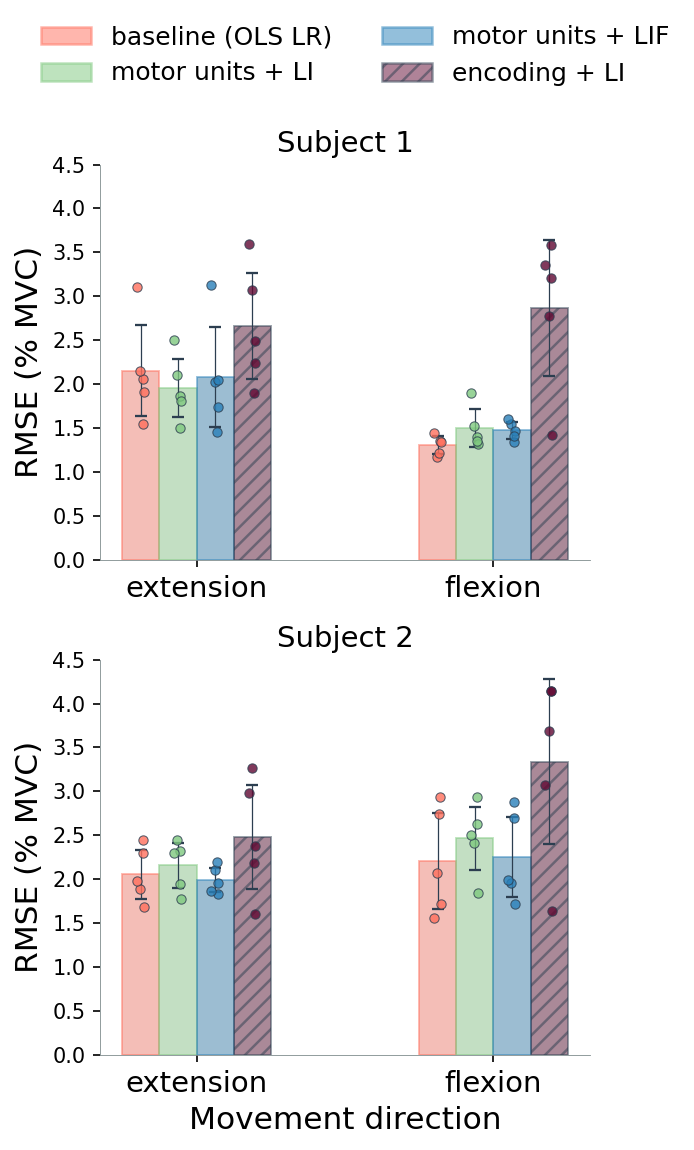

In [48]:
subjects = ["S1", "S2"]

plot_metric = 'RMSE_test_mean'
scatter_metric = plot_metric.replace('_mean', '')  # 'RMSE_test'

mean_sd_df = snn_topologies_df_with_baseline.groupby([SUBJECT_COL, TOPOLOGY_COL, 'topology_label', SIGN_MVC_COL], as_index=False)[plot_metric].mean()
mean_sd_df[f'{plot_metric}_std'] = snn_topologies_df_with_baseline.groupby([SUBJECT_COL, TOPOLOGY_COL, 'topology_label',SIGN_MVC_COL])['RMSE_test_std'].mean().values

# SNN: use all individual samples (no aggregation)
samples_df['topology_label'] = samples_df[TOPOLOGY_COL].map(topology_to_label)
shared_cols = [SUBJECT_COL, SIGN_MVC_COL, TOPOLOGY_COL, 'topology_label', scatter_metric]

# SNN: one point per finger (averaged over seeds × folds)
snn_raw = samples_df.groupby(
    [SUBJECT_COL, SIGN_MVC_COL, TOPOLOGY_COL, 'topology_label', FING_ID_COL], as_index=False
)[scatter_metric].mean()

# Baseline: one point per finger (mean_metrics_cv already has FING_ID_COL)
baseline_raw = mean_metrics_cv.copy()
baseline_raw['topology_label'] = 'baseline (OLS LR)'
baseline_raw[TOPOLOGY_COL] = 'baseline'
if f'{scatter_metric}_mean' in baseline_raw.columns:
    baseline_raw = baseline_raw.rename(columns={f'{scatter_metric}_mean': scatter_metric})

raw_scatter_df = pd.concat([snn_raw[shared_cols], baseline_raw[shared_cols]], ignore_index=True)

create_barplot_for_topology(
    subjects, mean_sd_df,
    plot_metric, color_palette, hatch_pattern,
    raw_df=raw_scatter_df,
    save_fig=True,
    output_figures_dir=output_figures_dir,
    source_data_path=os.path.join(project_dir, source_data_main_file),
    sheet_name='Fig8d_comparison'
)

In [80]:
for topo in samples_df['topology_label'].dropna().unique():
    print(f"\n{topo}")
    for seed in samples_df[TORCH_SEED_COL].dropna().unique():
        sub_df = samples_df[
            (samples_df['topology_label'] == topo) &
            (samples_df[SUBJECT_COL] == 'S1') &
            (samples_df[SIGN_MVC_COL] == -1) &
            (samples_df[TORCH_SEED_COL] == seed)
        ].groupby(FING_ID_COL)[scatter_metric].mean()
        print(f"  seed={seed}: mean={sub_df.mean():.3f}, std={sub_df.std():.3f}, vals={np.array(sub_df.values, dtype=float).round(3)}")


encoding + leaky
  seed=8: mean=2.563, std=0.576, vals=[2.229 3.091 2.332 1.919 3.246]
  seed=64: mean=3.086, std=1.580, vals=[2.35  3.079 2.3   1.895 5.807]
  seed=28: mean=2.521, std=0.569, vals=[2.223 3.072 2.27  1.873 3.167]
  seed=73: mean=2.535, std=0.583, vals=[2.231 3.148 2.307 1.849 3.141]
  seed=89: mean=2.788, std=0.976, vals=[2.243 3.094 2.267 1.972 4.363]
  seed=9: mean=2.535, std=0.599, vals=[2.215 3.116 2.236 1.881 3.227]
  seed=29: mean=2.511, std=0.565, vals=[2.2   2.991 2.239 1.904 3.223]
  seed=90: mean=2.554, std=0.579, vals=[2.21  3.03  2.356 1.897 3.278]
  seed=15: mean=2.956, std=0.991, vals=[2.217 3.039 4.419 1.878 3.229]
  seed=0: mean=2.554, std=0.579, vals=[2.25  3.088 2.22  1.956 3.258]

motor units + leaky
  seed=8: mean=1.944, std=0.376, vals=[1.836 2.079 1.822 1.484 2.499]
  seed=64: mean=1.970, std=0.385, vals=[1.886 2.141 1.784 1.513 2.529]
  seed=28: mean=1.954, std=0.360, vals=[1.858 2.088 1.801 1.532 2.492]
  seed=73: mean=1.947, std=0.364, vals=[1.

# Plot predictions

In [ ]:
subjects = ["S1","S2"]
results_dir = 'output_files'
selected_scale = 0.1
selected_tau = 0.1
selected_thr = 0.1
y_compiled_df_snn_encoding = cr.load_and_parse_snn_data_to_df(dt=0.01, subject_list=subjects,
                                                                    data_type='y_df_cv_snn',
                                                                    network_topology=f'{ENC_SHALLOW_LEAKY}',
                                                                    results_dir=results_dir,
                                                                    config=config)

y_compiled_df_snn_encoding =  y_compiled_df_snn_encoding [(y_compiled_df_snn_encoding[ENC_ALIF_SCALE_COL] == selected_scale) & 
                                    (y_compiled_df_snn_encoding[ENC_THRESHOLD_TAU_COL] == selected_tau) & 
                                    (y_compiled_df_snn_encoding[ENC_SPK_THRESH1_COL]==selected_thr)&
                                    (y_compiled_df_snn_encoding[EPOCHS_COL] == 100)]


y_compiled_df_snn_spiking = cr.load_and_parse_snn_data_to_df(dt=0.01, subject_list=subjects,
                                                                    data_type='y_df_cv_snn',
                                                                    network_topology=f'{SHALLOW_SPIKING_DOUBLE_FILTER}',
                                                                    results_dir=results_dir,
                                                                    config=config)

y_compiled_df_snn_leaky = cr.load_and_parse_snn_data_to_df(dt=0.01, subject_list=subjects,
                                                                    data_type='y_df_cv_snn',
                                                                    network_topology=f'{SHALLOW_LEAKY}',
                                                                    results_dir=results_dir,
                                                                    config=config)

y_compiled_df_conv_separate = cr.load_and_parse_df_data(subject_list=subjects, data_type='y_df',
                                                        config=config, results_dir=results_dir,
                                                        )
y_compiled_df_conv_separate = y_compiled_df_conv_separate[y_compiled_df_conv_separate[EMG_COL]=='intra']
mask_sub_mvc = (y_compiled_df_conv_separate[SUBJECT_COL].isin(subjects)) & (y_compiled_df_conv_separate[MVC_COL]==mvc)
y_compiled_df_conv_separate = y_compiled_df_conv_separate[mask_sub_mvc]

In [82]:
def mask_torch_seed(df, torch_seed):
    """
    Masks the dataframe based on the given torch seed.
    """
    if torch_seed is None:
        df_seed = df[df[TORCH_SEED_COL].isnull()]
    else:
        df_seed = df[df[TORCH_SEED_COL] == torch_seed]
    return df_seed

In [83]:
# rename a single column
type_pred_metric = 'post'

y_compiled_df_snn_encoding = y_compiled_df_snn_encoding.rename(columns={f'y_pred_test': f'y_pred_test_{type_pred_metric}'})
y_compiled_df_snn_encoding[TOPOLOGY_COL] = ENC_SHALLOW_LEAKY


y_compiled_df_snn_spiking= y_compiled_df_snn_spiking.rename(columns={f'y_pred_test': f'y_pred_test_{type_pred_metric}'})
y_compiled_df_snn_spiking[TOPOLOGY_COL] = SHALLOW_SPIKING_DOUBLE_FILTER

y_compiled_df_snn_leaky= y_compiled_df_snn_leaky.rename(columns={f'y_pred_test': f'y_pred_test_{type_pred_metric}'})
y_compiled_df_snn_leaky[TOPOLOGY_COL] = SHALLOW_LEAKY

# select a single torch_seed value as a representative example
y_compiled_df_snn_encoding = mask_torch_seed(y_compiled_df_snn_encoding, select_torch_seed)
y_compiled_df_snn_spiking = mask_torch_seed(y_compiled_df_snn_spiking, select_torch_seed)

# consider only inference mode
y_compiled_df_snn_encoding_inf = y_compiled_df_snn_encoding[y_compiled_df_snn_encoding[MODE_COL] == 'inference']
y_compiled_df_snn_spiking_inf= y_compiled_df_snn_spiking[y_compiled_df_snn_spiking[MODE_COL] == 'inference']
y_compiled_df_snn_leaky_inf= y_compiled_df_snn_leaky[y_compiled_df_snn_leaky[MODE_COL] == 'inference']

# concatenate both dataframes
y_compiled_df_snn_conv = pd.concat([y_compiled_df_conv_separate, 
                                    y_compiled_df_snn_spiking_inf,
                                    y_compiled_df_snn_encoding_inf,
                                    y_compiled_df_snn_leaky_inf], axis=0, ignore_index=True)

['S1', 'S1'] ['intra', 'intra'] [-1, -1] [15, 15] ['MU spike count', 'MU spike times'] [1, 1]
Comparing models:['intra mu spike count', 'intra mu spike times']
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
topology string:leaky_spiking_encoding_leaky_
Saving figure to S1_ypred_15_leaky_spiking_encoding_leaky_testrep_1_testsign_-1.pdf
Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataMain.xlsx in sheet 'Fig10_pred_encoding'.


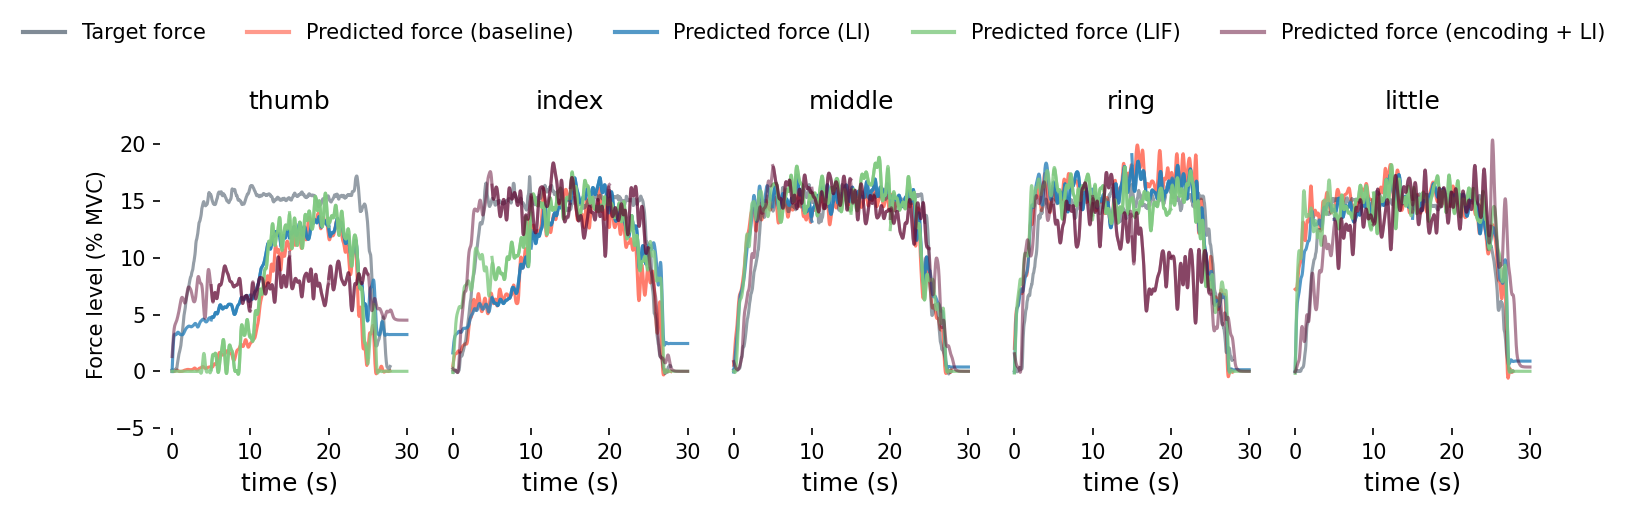

In [85]:
# Updates colors for the case of iEMG only
models_palette_dict = {'intra mu spike count': '#FF6F5C', #COLORS['orange'],
                       f'intra mu spike times {ENC_SHALLOW_LEAKY}': COLORS['burgundy'],
                       f'intra mu spike times {SHALLOW_SPIKING_DOUBLE_FILTER}': sns.color_palette(palette='Accent')[0],
                       f'intra mu spike times {SHALLOW_LEAKY}': COLORS['belize'],
                       }

subjects = ["S1", "S1"]
emg_types = ["intra", "intra"]
sign_mvcs = [-1]*len(emg_types)
mvcs = [15] * len(emg_types)
input_types = [INPUT_TYPE_SP_COUNT, INPUT_TYPE_SP_TIMES]
reps = [1] * len(emg_types)
snn_params_for_topology = {SHALLOW_LEAKY:flat_leaky_config,
                           SHALLOW_SPIKING_DOUBLE_FILTER:flat_spiking_config,
                           ENC_SHALLOW_LEAKY: flat_config}

print(subjects, emg_types, sign_mvcs, mvcs, input_types, reps)
cr.plot_pred_of_models_target_only_different_topologies(data_config, 
                                                        dataset,
                                                        y_compiled_df_snn_conv[y_compiled_df_snn_conv[SEGMENT_HOLD_COL]==False],
                                                        subjects, emg_types,
                                                        sign_mvcs, mvcs, input_types,
                                                        reps, 
                                                        snn_params_for_topology,
                                                        models_palette_dict=models_palette_dict,
                                                        ylim=(-5,22),
                                                        xlim= None, # for entire profile: None | zoomed-in plateau: (5,10)
                                                        save_figure=True,
                                                        pred_force_alpha=0.9,
                                                        pred_linestyle='solid',
                                                        compiled_results_dir=output_figures_dir,
                                                        show_topology=[SHALLOW_LEAKY, SHALLOW_SPIKING_DOUBLE_FILTER, ENC_SHALLOW_LEAKY],
                                                        show_custom_annotation=False, # show annotation in case of zoomed-in: True
                                                        source_data_path=os.path.join(project_dir, source_data_main_file),
                                                        sheet_name='Fig10_pred_encoding'
                                                        
                            )